# 04. Model Building and Evaluation

This notebook contains the model building and evaluation process. It trains Linear Regression, Random Forest, and XGBoost models for each store and evaluates them using MAE and RMSE.

In [52]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
# from xgboost import XGBRegressor

# Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [53]:
# Load Processed Data
train_df = pd.read_csv('processed_train.csv')

# Ensure Sales is numeric
train_df['Sales'] = pd.to_numeric(train_df['Sales'], errors='coerce')

# Drop rows where Sales is NaN (if any)
train_df.dropna(subset=['Sales'], inplace=True)

print("Data loaded successfully.")

Data loaded successfully.


In [54]:
# Initialize Metrics Storage
mae_scores = {
    'LinearRegression': [],
    'RandomForestRegressor': [],
    'GradientBoostingRegressor': []
}
rmse_scores = {
    'LinearRegression': [],
    'RandomForestRegressor': [],
    'GradientBoostingRegressor': []
}

# Group by Store
rossmann_dic = dict(list(train_df.groupby('Store')))

print(f"Processing {len(rossmann_dic)} stores... This may take a while.")

Processing 1115 stores... This may take a while.


In [ ]:
# Model Training and Evaluation Loop

for store_id, store_data in rossmann_dic.items():
    # Ensure store has sales data and enough samples for splitting
    if store_data.empty or len(store_data) < 10:  # Increased threshold slightly for safety
        continue

    # Define Features (X) and Target (y)
    # Drop Sales and Store (ID)
    X = store_data.drop(["Sales", "Store"], axis=1)
    y = store_data["Sales"]

    # Handle any remaining non-numeric columns if missed in Step 03
    X = X.select_dtypes(include=[np.number])

    # Split data into training and validation sets (80% train, 20% validation)
    try:
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    except ValueError:
        continue

    # Skip if training or validation sets are too small
    if len(X_train) == 0 or len(X_val) == 0:
        continue

    # --- Linear Regression ---
    try:
        lreg = LinearRegression()
        lreg.fit(X_train, y_train)
        y_pred_lreg = lreg.predict(X_val)
        mae_scores['LinearRegression'].append(mean_absolute_error(y_val, y_pred_lreg))
        rmse_scores['LinearRegression'].append(np.sqrt(mean_squared_error(y_val, y_pred_lreg)))
    except Exception as e:
        pass

    # --- Random Forest Regressor ---
    try:
        # Reduced n_estimators to 10 for speed in demo, increase for production
        rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) 
        rf_reg.fit(X_train, y_train)
        y_pred_rf = rf_reg.predict(X_val)
        mae_scores['RandomForestRegressor'].append(mean_absolute_error(y_val, y_pred_rf))
        rmse_scores['RandomForestRegressor'].append(np.sqrt(mean_squared_error(y_val, y_pred_rf)))
    except Exception as e:
        pass

    # --- XGBoost Regressor ---
    try:
        xgb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
        xgb_reg.fit(X_train, y_train)
        y_pred_xgb = xgb_reg.predict(X_val)
        mae_scores['GradientBoostingRegressor'].append(mean_absolute_error(y_val, y_pred_xgb))
        rmse_scores['GradientBoostingRegressor'].append(np.sqrt(mean_squared_error(y_val, y_pred_xgb)))
    except Exception as e:
        pass

print("Model evaluation complete for all stores.")

Model evaluation complete for all stores.


In [60]:
# Calculate Averages
avg_mae = {model: np.mean(scores) for model, scores in mae_scores.items() if scores}
avg_rmse = {model: np.mean(scores) for model, scores in rmse_scores.items() if scores}

print("\nAverage MAE across all stores:")
for model, mae in avg_mae.items():
    print(f"- {model}: {mae:.2f}")

print("\nAverage RMSE across all stores:")
for model, rmse in avg_rmse.items():
    print(f"- {model}: {rmse:.2f}")


Average MAE across all stores:
- LinearRegression: 1047.12
- RandomForestRegressor: 1063.98
- GradientBoostingRegressor: 1042.20

Average RMSE across all stores:
- LinearRegression: 1411.45
- RandomForestRegressor: 1429.91
- GradientBoostingRegressor: 1404.44


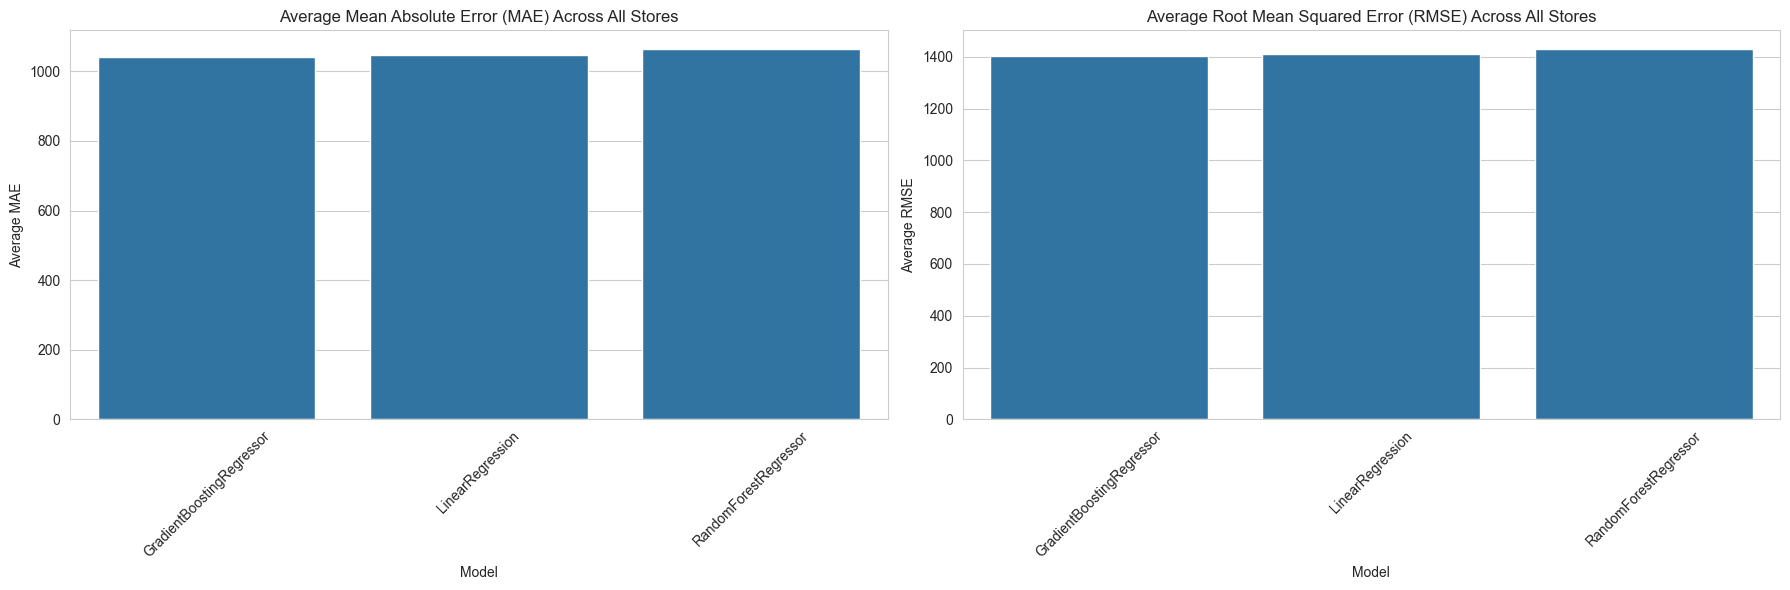

In [57]:
# Visualization
metrics_df = pd.DataFrame({
    'Model': list(avg_mae.keys()),
    'MAE': list(avg_mae.values()),
    'RMSE': list(avg_rmse.values())
})

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# MAE plot
sns.barplot(x='Model', y='MAE', data=metrics_df.sort_values(by='MAE'), ax=axes[0])
axes[0].set_title('Average Mean Absolute Error (MAE) Across All Stores')
axes[0].set_ylabel('Average MAE')
axes[0].tick_params(axis='x', rotation=45)

# RMSE plot
sns.barplot(x='Model', y='RMSE', data=metrics_df.sort_values(by='RMSE'), ax=axes[1])
axes[1].set_title('Average Root Mean Squared Error (RMSE) Across All Stores')
axes[1].set_ylabel('Average RMSE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

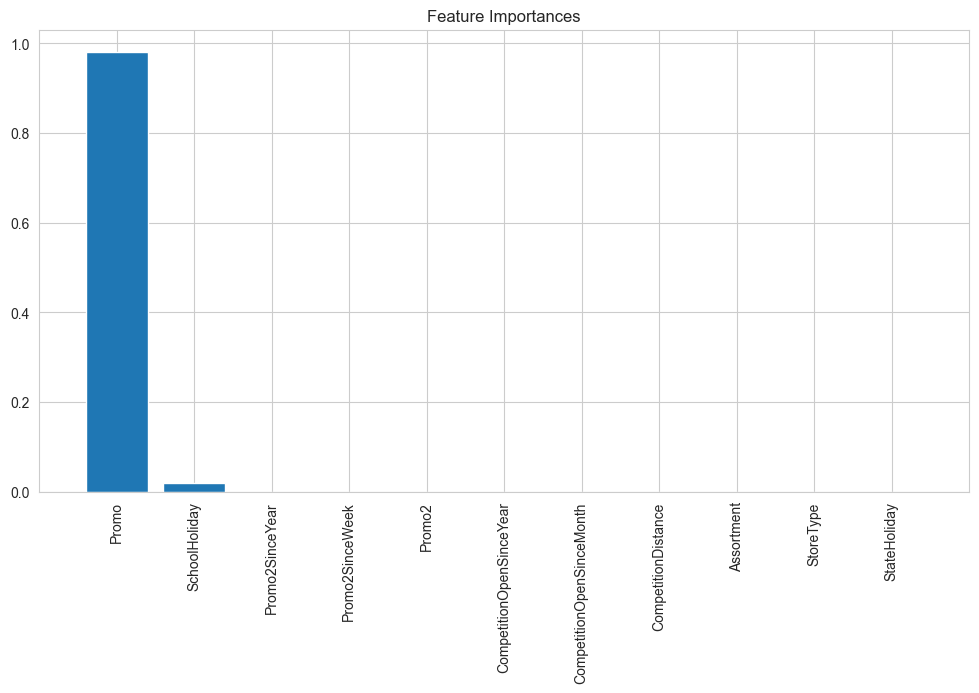

In [58]:
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [59]:
# Summary
if avg_mae and avg_rmse:
    best_mae_model = min(avg_mae, key=avg_mae.get)
    best_rmse_model = min(avg_rmse, key=avg_rmse.get)

    print(f"\nSummary of Model Performance:")
    print(f"The model with the lowest average MAE is {best_mae_model} (MAE: {avg_mae[best_mae_model]:.2f}).")
    print(f"The model with the lowest average RMSE is {best_rmse_model} (RMSE: {avg_rmse[best_rmse_model]:.2f}).")
else:
    print("No valid scores computed.")


Summary of Model Performance:
The model with the lowest average MAE is GradientBoostingRegressor (MAE: 1042.20).
The model with the lowest average RMSE is GradientBoostingRegressor (RMSE: 1404.44).
